# Lib

In [1]:
# !pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
import os
from pathlib import Path
from PIL import Image
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import torch
import torch.nn as nn
import torch.distributed as dist

from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample


from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [3]:
import torch

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))

torch: 2.10.0+cu128
torch cuda: 12.8
cuda available: True
gpu: Tesla T4
capability: (7, 5)


# Data

In [4]:
dataset_dir = Path("/kaggle/input/datasets/duongnguyenquy/mosquitoes-compsci760")

# Image
image_dir = dataset_dir / "images" / "images"
# image_dir = dataset_dir / "image_crop" / "image_crop"

# Annotation
annotation_path = r"/kaggle/input/datasets/duongnguyenquy/mosquitoes-compsci760/labels/annotations.csv"
# annotation_path = dataset_dir /"image_crop"/"image_crop"/ "cropped_annotations.csv"

annotations = pd.read_csv(annotation_path)
annotations.head()

,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label
0,train_00000.jpeg,2448,3264,1301,1546,1641,2096,albopictus
1,train_00001.jpeg,3024,4032,900,1897,1950,2990,albopictus
2,train_00002.jpeg,768,1024,220,58,659,808,albopictus
3,train_00003.jpeg,3456,4608,1169,2364,1586,2826,albopictus
4,train_00004.jpeg,1024,1365,129,231,697,1007,culex


In [5]:
annotations.shape

(10357, 8)

In [6]:
image_df = (
    annotations.groupby("img_fName")["class_label"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

print("Number of images:", len(image_df))
print(image_df["class_label"].value_counts())
image_df.head()

Number of images: 10357
class_label
albopictus            4612
culex                 4563
culiseta               622
japonicus-koreicus     429
anopheles               84
aegypti                 47
Name: count, dtype: int64


,img_fName,class_label
0,train_00000.jpeg,albopictus
1,train_00001.jpeg,albopictus
2,train_00002.jpeg,albopictus
3,train_00003.jpeg,albopictus
4,train_00004.jpeg,culex


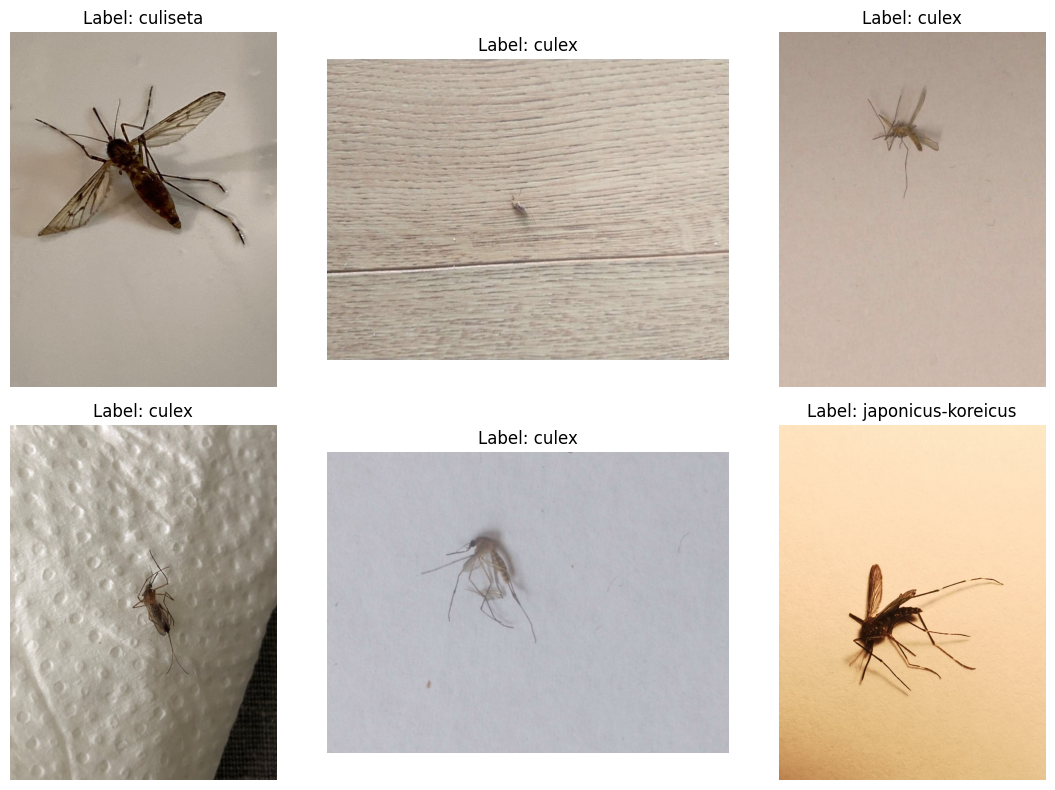

In [7]:
# number of images to show
num_images = 6

sample_df = annotations.sample(num_images, random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = image_dir / row["img_fName"]   # adjust column name if needed
    
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {row['class_label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Preprocessing

In [8]:
label_encoder = LabelEncoder()
image_df["label_id"] = label_encoder.fit_transform(image_df["class_label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(class_names)
print("Num classes:", num_classes)

['aegypti', 'albopictus', 'anopheles', 'culex', 'culiseta', 'japonicus-koreicus']
Num classes: 6


# Split

In [9]:
def oversample_dataframe(df, label_col, random_state=42):
    max_count = df[label_col].value_counts().max()
    balanced = []

    for label in df[label_col].unique():
        subset = df[df[label_col] == label]
        upsampled = resample(
            subset,
            replace=True,
            n_samples=max_count,
            random_state=random_state
        )
        balanced.append(upsampled)

    return pd.concat(balanced).sample(frac=1, random_state=random_state).reset_index(drop=True)


from imblearn.over_sampling import ADASYN
import pandas as pd

def adasyn_resample_dataframe(df, label_col, random_state=42):
    """
    Resample a DataFrame using ADASYN to balance classes.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        label_col (str): Name of the target column
        random_state (int): Random seed for reproducibility
        
    Returns:
        pd.DataFrame: Balanced DataFrame with synthetic samples
    """
    X = df.drop(columns=[label_col])
    y = df[label_col]

    # Initialize ADASYN
    adasyn = ADASYN(random_state=random_state)

    # Fit and resample
    X_res, y_res = adasyn.fit_resample(X, y)

    # Reconstruct DataFrame
    df_resampled = pd.DataFrame(X_res, columns=X.columns)
    df_resampled[label_col] = y_res

    # Shuffle the DataFrame
    return df_resampled.sample(frac=1, random_state=random_state).reset_index(drop=True)

In [10]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=42,
    stratify=image_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)


#Oversampling method
train_df = oversample_dataframe(train_df, label_col="label_id")

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain label distribution after oversampling:")
print(train_df["label_id"].value_counts())

Train: 19368
Val: 1554
Test: 1554

Train label distribution after oversampling:
label_id
5    3228
1    3228
2    3228
3    3228
0    3228
4    3228
Name: count, dtype: int64


In [11]:
# train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
#     lambda x: x.sample(min(len(x), 50), random_state=42)
# ).reset_index(drop=True)

# val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
#     lambda x: x.sample(min(len(x), 20), random_state=42)
# ).reset_index(drop=True)

# test_subset_df = test_df.groupby("label_id", group_keys=False).apply(
#     lambda x: x.sample(min(len(x), 20), random_state=42)
# ).reset_index(drop=True)

# print("Subset Train:", len(train_subset_df))
# print("Subset Val:", len(val_subset_df))
# print("Subset Test:", len(test_subset_df))

# Modeling

## ENV

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Using: cuda
GPU: Tesla T4
Capability: (7, 5)


## Transform

In [13]:
image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Dataset

In [14]:
class MosquitoImageDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.image_dir / row["img_fName"]
        image = Image.open(image_path).convert("RGB")
        label = int(row["label_id"])

        if self.transform:
            image = self.transform(image)

        return image, label


In [15]:
train_dataset = MosquitoImageDataset(train_df, image_dir, transform=train_transform)
val_dataset = MosquitoImageDataset(val_df, image_dir, transform=eval_transform)
test_dataset = MosquitoImageDataset(test_df, image_dir, transform=eval_transform)

# Subset
# train_dataset = MosquitoImageDataset(train_subset_df, image_dir, transform=train_transform)
# val_dataset = MosquitoImageDataset(val_subset_df, image_dir, transform=eval_transform)
# test_dataset = MosquitoImageDataset(test_subset_df, image_dir, transform=eval_transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [16]:
# load pretrained EfficientNetV2-S
# model = models.efficientnet_v2_s(
#     weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
# )

model = models.efficientnet_v2_l(
    weights=models.EfficientNet_V2_L_Weights.IMAGENET1K_V1
)

# replace classifier
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_l-59c71312.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_l-59c71312.pth


100%|██████████| 455M/455M [00:02<00:00, 179MB/s]


In [17]:
# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

# Training process

In [18]:
output_dir = Path("/kaggle/working/")
output_dir.mkdir(parents=True, exist_ok=True)

num_epochs = 70
patience = 5
best_val_loss = float("inf")
early_stop_counter = 0

print("Start training...")
print("Selected device:", device)
print("Model device:", next(model.parameters()).device)

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch + 1}/{num_epochs} =====")
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        if batch_idx == 0:
            print("Before move:")
            print("  images device:", images.device)
            print("  labels device:", labels.device)

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if batch_idx == 0:
            print("After move:")
            print("  images device:", images.device)
            print("  labels device:", labels.device)
            print("  model device:", next(model.parameters()).device)

            if torch.cuda.is_available():
                print("  GPU memory allocated:", torch.cuda.memory_allocated() / 1024**2, "MB")
                print("  GPU memory reserved:", torch.cuda.memory_reserved() / 1024**2, "MB")

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        if batch_idx % 10 == 0:
            print(f"[Train] Epoch {epoch + 1} Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            if batch_idx % 10 == 0:
                print(f"[Val] Epoch {epoch + 1} Batch {batch_idx}/{len(val_loader)} | Loss: {loss.item():.4f}")

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    checkpoint_path = output_dir / f"checkpoint_epoch_{epoch + 1}.pth"
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "class_names": class_names
    }, checkpoint_path)

    print(f"Saved checkpoint to: {checkpoint_path}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0

        best_model_path = output_dir / "best_model.pth"
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "class_names": class_names
        }, best_model_path)

        print(f"Best model updated and saved to: {best_model_path}")
    else:
        early_stop_counter += 1
        print(f"No improvement. Early stop counter: {early_stop_counter}/{patience}")

    if early_stop_counter >= patience:
        print("Early stopping triggered.")
        break

print("Training completed.")

Start training...
Selected device: cuda
Model device: cuda:0

===== Epoch 1/70 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 477.03466796875 MB
  GPU memory reserved: 506.0 MB
[Train] Epoch 1 Batch 0/606 | Loss: 2.0182
[Train] Epoch 1 Batch 10/606 | Loss: 2.0712
[Train] Epoch 1 Batch 20/606 | Loss: 1.8898
[Train] Epoch 1 Batch 30/606 | Loss: 2.0338
[Train] Epoch 1 Batch 40/606 | Loss: 1.8663
[Train] Epoch 1 Batch 50/606 | Loss: 2.0819
[Train] Epoch 1 Batch 60/606 | Loss: 2.0402
[Train] Epoch 1 Batch 70/606 | Loss: 1.9545
[Train] Epoch 1 Batch 80/606 | Loss: 1.7116
[Train] Epoch 1 Batch 90/606 | Loss: 1.9696
[Train] Epoch 1 Batch 100/606 | Loss: 2.0579
[Train] Epoch 1 Batch 110/606 | Loss: 1.9187
[Train] Epoch 1 Batch 120/606 | Loss: 1.9712
[Train] Epoch 1 Batch 130/606 | Loss: 1.8755
[Train] Epoch 1 Batch 140/606 | Loss: 1.9077
[Train] Epoch 1 Batch 150/606 | Loss: 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[Val] Epoch 1 Batch 0/49 | Loss: 1.7097
[Val] Epoch 1 Batch 10/49 | Loss: 1.8463
[Val] Epoch 1 Batch 20/49 | Loss: 1.7967
[Val] Epoch 1 Batch 30/49 | Loss: 1.7760
[Val] Epoch 1 Batch 40/49 | Loss: 1.7831
Epoch 1/70 | Train Loss: 1.9058 | Train Acc: 0.1656 | Val Loss: 1.7908 | Val Acc: 0.2059
Saved checkpoint to: /kaggle/working/checkpoint_epoch_1.pth
Best model updated and saved to: /kaggle/working/best_model.pth

===== Epoch 2/70 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 494.37548828125 MB
  GPU memory reserved: 1366.0 MB
[Train] Epoch 2 Batch 0/606 | Loss: 1.8304
[Train] Epoch 2 Batch 10/606 | Loss: 1.8987
[Train] Epoch 2 Batch 20/606 | Loss: 1.9539
[Train] Epoch 2 Batch 30/606 | Loss: 2.0216
[Train] Epoch 2 Batch 40/606 | Loss: 1.8357
[Train] Epoch 2 Batch 50/606 | Loss: 1.9479
[Train] Epoch 2 Batch 60/606 | Loss: 1.9748
[Train] Epoch 2 Batch 70/606 | Loss: 1

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[Val] Epoch 2 Batch 0/49 | Loss: 1.6858
[Val] Epoch 2 Batch 10/49 | Loss: 1.8415
[Val] Epoch 2 Batch 20/49 | Loss: 1.7734
[Val] Epoch 2 Batch 30/49 | Loss: 1.7580
[Val] Epoch 2 Batch 40/49 | Loss: 1.7697
Epoch 2/70 | Train Loss: 1.8501 | Train Acc: 0.1916 | Val Loss: 1.7755 | Val Acc: 0.2233
Saved checkpoint to: /kaggle/working/checkpoint_epoch_2.pth
Best model updated and saved to: /kaggle/working/best_model.pth

===== Epoch 3/70 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 494.37548828125 MB
  GPU memory reserved: 1366.0 MB
[Train] Epoch 3 Batch 0/606 | Loss: 1.8414
[Train] Epoch 3 Batch 10/606 | Loss: 1.9642
[Train] Epoch 3 Batch 20/606 | Loss: 1.8176
[Train] Epoch 3 Batch 30/606 | Loss: 1.7502
[Train] Epoch 3 Batch 40/606 | Loss: 1.7769
[Train] Epoch 3 Batch 50/606 | Loss: 1.8544
[Train] Epoch 3 Batch 60/606 | Loss: 1.9667
[Train] Epoch 3 Batch 70/606 | Loss: 1

...

[Val] Epoch 24 Batch 0/49 | Loss: 1.5239
[Val] Epoch 24 Batch 10/49 | Loss: 1.6420
[Val] Epoch 24 Batch 20/49 | Loss: 1.4848
[Val] Epoch 24 Batch 30/49 | Loss: 1.4060
[Val] Epoch 24 Batch 40/49 | Loss: 1.5155
Epoch 24/70 | Train Loss: 1.5215 | Train Acc: 0.3960 | Val Loss: 1.5376 | Val Acc: 0.3925
Saved checkpoint to: /kaggle/working/checkpoint_epoch_24.pth
No improvement. Early stop counter: 3/5

===== Epoch 25/70 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 494.37548828125 MB
  GPU memory reserved: 1366.0 MB
[Train] Epoch 25 Batch 0/606 | Loss: 1.5362
[Train] Epoch 25 Batch 10/606 | Loss: 1.5095
[Train] Epoch 25 Batch 20/606 | Loss: 1.4183
[Train] Epoch 25 Batch 30/606 | Loss: 1.4417
[Train] Epoch 25 Batch 40/606 | Loss: 1.5935
[Train] Epoch 25 Batch 50/606 | Loss: 1.5442
[Train] Epoch 25 Batch 60/606 | Loss: 1.6634
[Train] Epoch 25 Batch 70/606 | Loss: 1.3570
[T

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[Val] Epoch 25 Batch 0/49 | Loss: 1.5241
[Val] Epoch 25 Batch 10/49 | Loss: 1.6520
[Val] Epoch 25 Batch 20/49 | Loss: 1.4812
[Val] Epoch 25 Batch 30/49 | Loss: 1.3937
[Val] Epoch 25 Batch 40/49 | Loss: 1.5089
Epoch 25/70 | Train Loss: 1.5155 | Train Acc: 0.3971 | Val Loss: 1.5267 | Val Acc: 0.4086
Saved checkpoint to: /kaggle/working/checkpoint_epoch_25.pth
No improvement. Early stop counter: 4/5

===== Epoch 26/70 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 494.37548828125 MB
  GPU memory reserved: 1366.0 MB
[Train] Epoch 26 Batch 0/606 | Loss: 1.5156
[Train] Epoch 26 Batch 10/606 | Loss: 1.5978
[Train] Epoch 26 Batch 20/606 | Loss: 1.6013
[Train] Epoch 26 Batch 30/606 | Loss: 1.4023
[Train] Epoch 26 Batch 40/606 | Loss: 1.4985
[Train] Epoch 26 Batch 50/606 | Loss: 1.7327
[Train] Epoch 26 Batch 60/606 | Loss: 1.7686
[Train] Epoch 26 Batch 70/606 | Loss: 1.5788
[T

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[Val] Epoch 26 Batch 0/49 | Loss: 1.5466
[Val] Epoch 26 Batch 10/49 | Loss: 1.6841
[Val] Epoch 26 Batch 20/49 | Loss: 1.5015
[Val] Epoch 26 Batch 30/49 | Loss: 1.4246
[Val] Epoch 26 Batch 40/49 | Loss: 1.5379
Epoch 26/70 | Train Loss: 1.5109 | Train Acc: 0.3960 | Val Loss: 1.5605 | Val Acc: 0.3745
Saved checkpoint to: /kaggle/working/checkpoint_epoch_26.pth
No improvement. Early stop counter: 5/5
Early stopping triggered.
Training completed.


# Evaluation

In [19]:
model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Confidence score
prob_dicts = [
    {class_names[i]: float(prob[i]) for i in range(len(class_names))}
    for prob in all_probs
]

In [20]:
acc = accuracy_score(all_labels, all_preds)
print("Test Accuracy:", round(acc, 4))

Test Accuracy: 0.3925


In [21]:
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average=None
)

per_class_accuracy = []

for i in range(len(class_names)):
    correct = np.sum((all_labels == i) & (all_preds == i))
    total = np.sum(all_labels == i)
    acc = correct / total if total > 0 else 0
    per_class_accuracy.append(acc)

per_class_df = pd.DataFrame({
    "class_name": class_names,
    "accuracy":per_class_accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

per_class_df

,class_name,accuracy,precision,recall,f1,support
0,aegypti,0.571429,0.016194,0.571429,0.031496,7
1,albopictus,0.485549,0.861538,0.485549,0.621072,692
2,anopheles,0.230769,0.014851,0.230769,0.027907,13
3,culex,0.293860,0.855319,0.293860,0.437432,684
4,culiseta,0.414894,0.138298,0.414894,0.207447,94
5,japonicus-koreicus,0.421875,0.136364,0.421875,0.206107,64


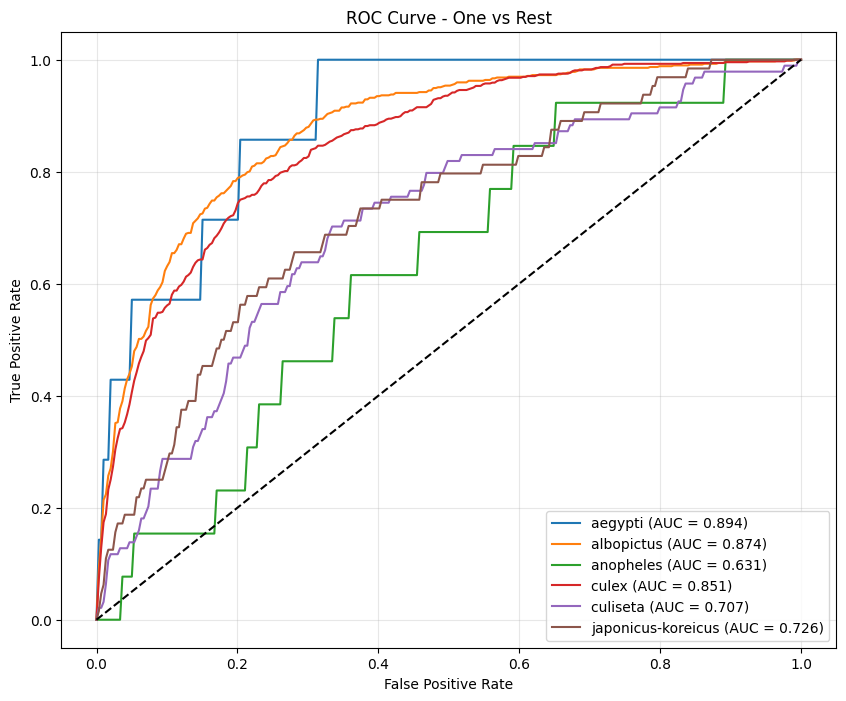

In [22]:
n_classes = len(class_names)
all_labels_bin = label_binarize(all_labels, classes=range(n_classes))

plt.figure(figsize=(10, 8))

mean_fpr = np.linspace(0, 1, 300)

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc_i = auc(fpr, tpr)

    # Smooth for visualization only
    tpr_smooth = np.interp(mean_fpr, fpr, tpr)
    tpr_smooth[0] = 0.0
    tpr_smooth[-1] = 1.0

    plt.plot(mean_fpr, tpr_smooth, label=f"{class_name} (AUC = {roc_auc_i:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - One vs Rest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

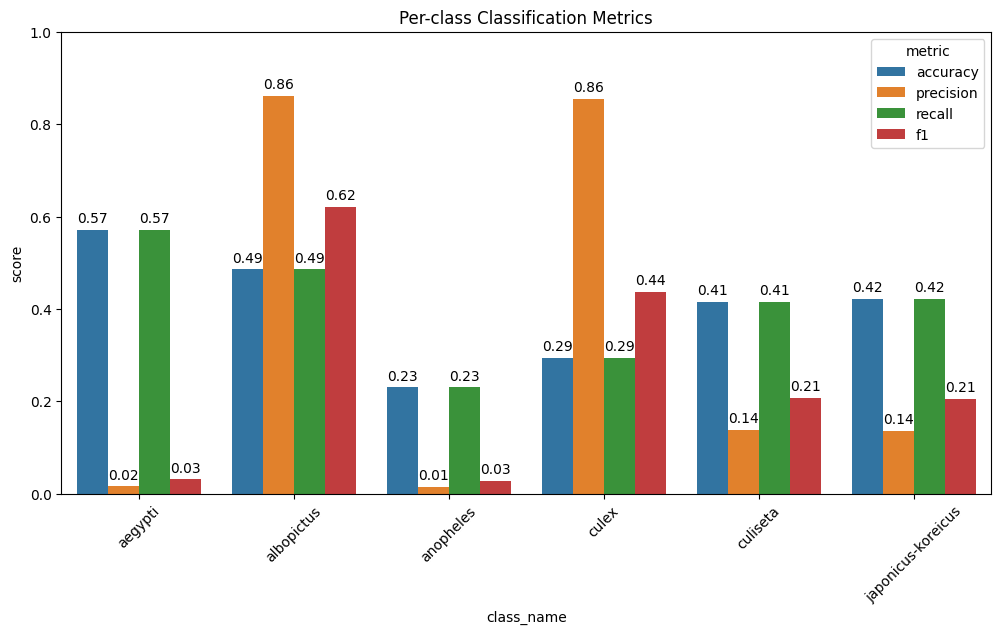

In [23]:
plot_df = per_class_df.melt(
    id_vars=["class_name"],
    value_vars=["accuracy", "precision", "recall", "f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=plot_df, x="class_name", y="score", hue="metric")

plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title("Per-class Classification Metrics")

# Add labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

In [24]:
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro"
)

# ===== ROC-AUC (One-vs-Rest) =====
roc_auc = roc_auc_score(
    all_labels,
    all_probs,              # shape: (n_samples, n_classes)
    multi_class="ovr",      # one-vs-rest
    average="macro"
)

# ===== Summary table =====
summary_df = pd.DataFrame([{
    "accuracy": acc,
    "precision_macro": precision_macro,
    "recall_macro": recall_macro,
    "f1_macro": f1_macro,
    "roc_auc_ovr": roc_auc
}])

print(summary_df)

   accuracy  precision_macro  recall_macro  f1_macro  roc_auc_ovr
0  0.421875         0.337094      0.403063  0.255243       0.7805


# Error analysis 

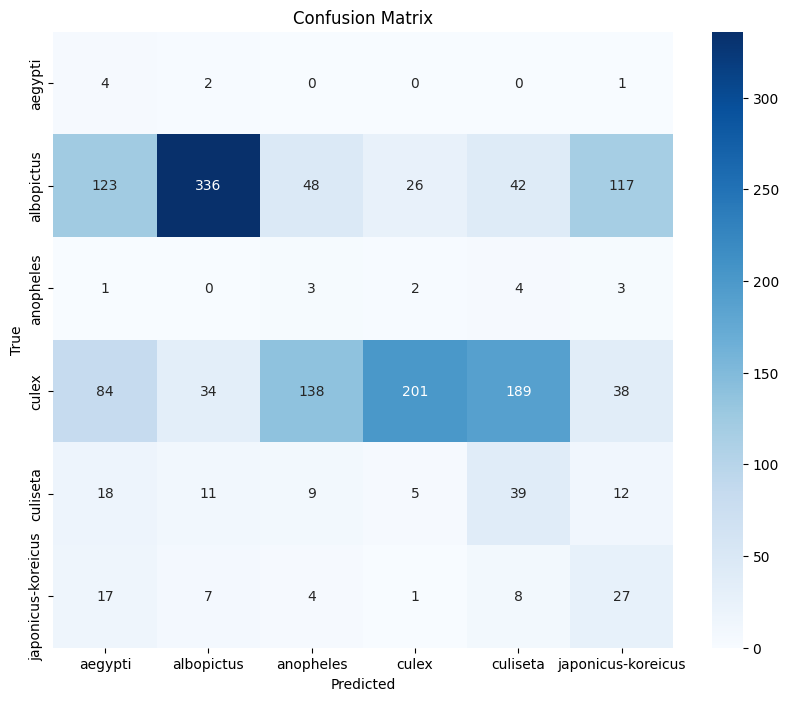

In [25]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [26]:
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

mis_idx = np.where(all_labels != all_preds)[0]
print("Total misclassified:", len(mis_idx))

image_paths = [
    str(image_dir / fname) 
    for fname in annotations["img_fName"]  # adjust column name if needed
]
# build error dataframe
error_df = pd.DataFrame({
    "true": all_labels[mis_idx],
    "pred": all_preds[mis_idx],
    "image_path": np.array(image_paths)[mis_idx],
    "probabilities": [prob_dicts[i] for i in mis_idx]
})

error_df.head()

Total misclassified: 944


,true,pred,image_path,probabilities
0,3,0,/kaggle/input/datasets/duongnguyenquy/mosquito...,"{'aegypti': 0.26562434434890747, 'albopictus':..."
1,3,4,/kaggle/input/datasets/duongnguyenquy/mosquito...,"{'aegypti': 0.08465791493654251, 'albopictus':..."
2,1,5,/kaggle/input/datasets/duongnguyenquy/mosquito...,"{'aegypti': 0.2134198248386383, 'albopictus': ..."
3,3,5,/kaggle/input/datasets/duongnguyenquy/mosquito...,"{'aegypti': 0.198086678981781, 'albopictus': 0..."
4,3,5,/kaggle/input/datasets/duongnguyenquy/mosquito...,"{'aegypti': 0.20099981129169464, 'albopictus':..."


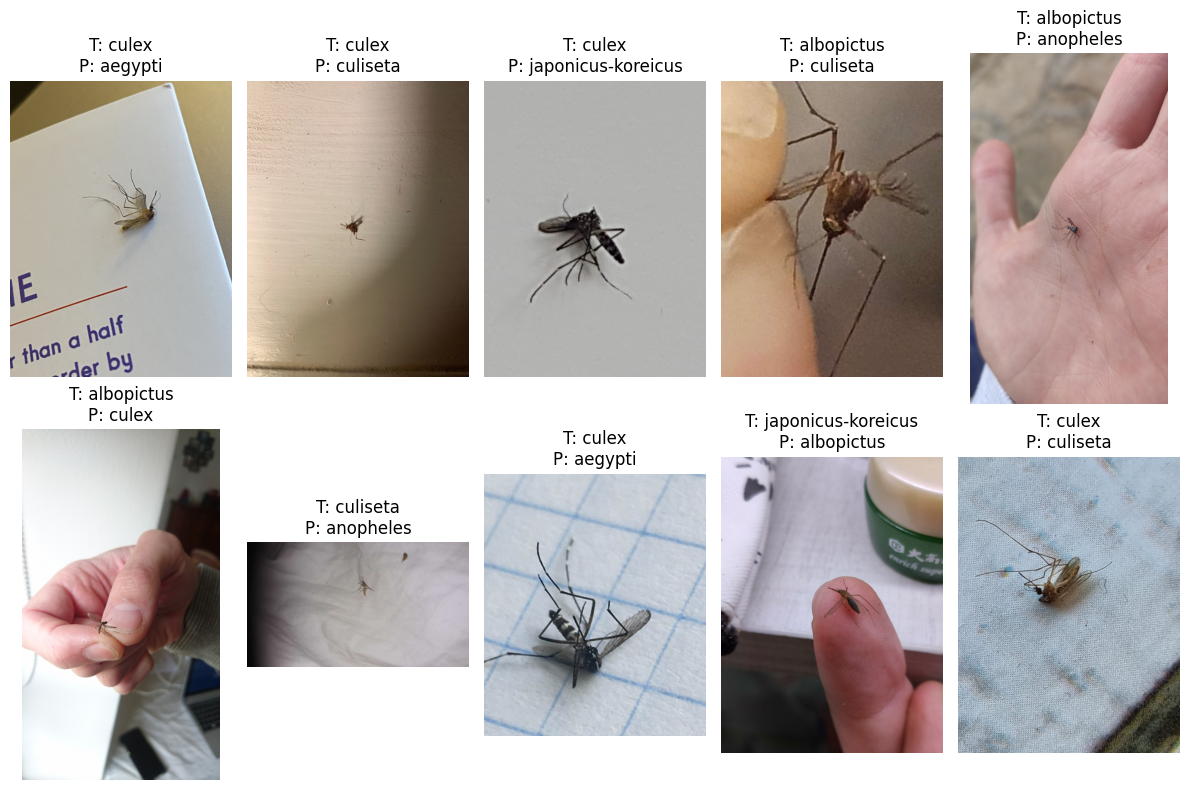

In [27]:
num_images = 10
sample_errors = error_df.sample(num_images, random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_errors.iterrows()):
    img = Image.open(row["image_path"])
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"T: {class_names[row['true']]}\nP: {class_names[row['pred']]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

confusions = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            confusions.append((class_names[i], class_names[j], cm[i, j]))

confusions = sorted(confusions, key=lambda x: x[2], reverse=True)

top_confusions = pd.DataFrame(confusions[:10], columns=["True", "Pred", "Count"])
print(top_confusions)

         True                Pred  Count
0       culex            culiseta    189
1       culex           anopheles    138
2  albopictus             aegypti    123
3  albopictus  japonicus-koreicus    117
4       culex             aegypti     84
5  albopictus           anopheles     48
6  albopictus            culiseta     42
7       culex  japonicus-koreicus     38
8       culex          albopictus     34
9  albopictus               culex     26


In [29]:
class_errors = []

for i, cls in enumerate(class_names):
    total = cm[i].sum()
    correct = cm[i, i]
    error_rate = 1 - (correct / total) if total > 0 else 0
    
    class_errors.append({
        "class": cls,
        "error_rate": error_rate
    })

error_rate_df = pd.DataFrame(class_errors).sort_values(by="error_rate", ascending=False)

print(error_rate_df)

                class  error_rate
2           anopheles    0.769231
3               culex    0.706140
4            culiseta    0.585106
5  japonicus-koreicus    0.578125
1          albopictus    0.514451
0             aegypti    0.428571


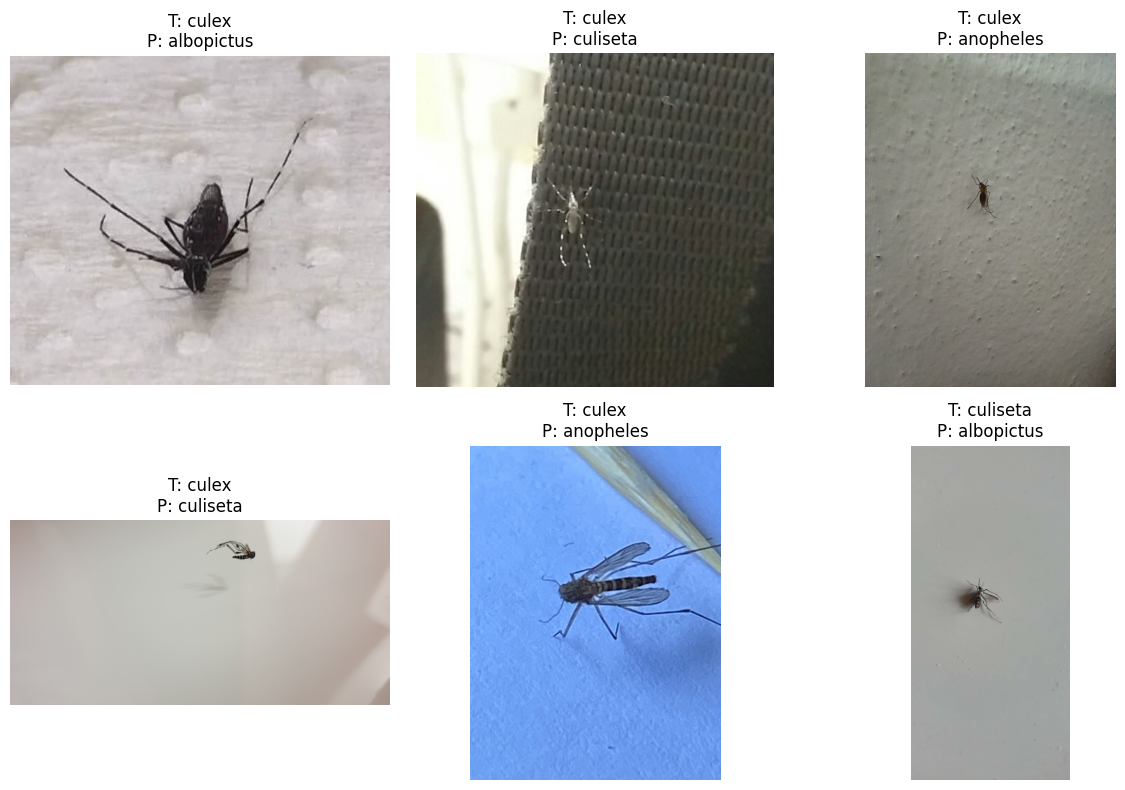

In [30]:
hard_classes = error_rate_df.head(3)["class"].values

subset = error_df[error_df["true"].isin([
    class_names.index(c) for c in hard_classes
])]

sample = subset.sample(min(6, len(subset)))

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"])
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"T: {class_names[row['true']]}\nP: {class_names[row['pred']]}")
    plt.axis("off")

plt.tight_layout()
plt.show()